In [2]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})

set_defaults({})


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt

fontsize = 14
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "cm",
    "font.size": fontsize,
    #'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents}',
    'figure.dpi': 200
})

In [4]:
from typing import Dict, Tuple, Optional

def get_last_file(path: Path) -> Path | None:
    # --- Step 1: Look for final files first ---
    final_candidates = [
        path / "TR_IRGNM_final.pkl",
        path / "FOM_IRGNM_final.pkl"
    ]
    
    for final_file in final_candidates:
        if final_file.exists():
            return final_file.name  # Return immediately if found
    
    # --- Step 2: If no final file exists, find the highest index file ---
    files = glob.glob(os.path.join(path, "TR_IRGNM_*.pkl"))
    files += glob.glob(os.path.join(path, "FOM_IRGNM_*.pkl"))

    indexed_files = []
    for f in files:
        match = re.search(r'(?:TR|FOM)_IRGNM_(\d+)\.pkl$', os.path.basename(f))
        if match:
            idx = int(match.group(1))
            indexed_files.append((idx, f))

    if indexed_files:
        _, max_file = max(indexed_files, key=lambda x: x[0])
        return Path(max_file).name

    print("No matching IRGNM result files found.")
    return None

def filter_and_reorder(d: Dict, pattern: str = r'.*FOM.*') -> Tuple[Dict, Optional[str]]:
    regex = re.compile(pattern)
    matching = [k for k in d if regex.search(k)]
    non_matching = [k for k in d if k not in matching]

    # Sort keys alphabetically within each group
    non_matching_sorted = sorted(non_matching)
    matching_sorted = sorted(matching)

    # Build the reordered dict: alphabetically sorted non-matching first, then matching ones
    reordered = {k: d[k] for k in non_matching_sorted}
    reordered.update({k: d[k] for k in matching_sorted})

    # Return reordered dict and the single matching key (if exactly one match)
    if len(matching_sorted) == 1:
        return reordered, matching_sorted[0]
    else:
        return reordered, None

In [5]:
#SAVE_PATH = Path('/home/dealii/workdir/figs')
SAVE_PATH = Path('/home/benedikt/Schreibtisch/error_stagnation')

########################################################################################

WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')
#WORK_DIR = Path('/home/dealii/workdir/experiments')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

subset = 'new_baseline'
obs_op = 'identity'
data_dir_path = WORK_DIR / 'pre_paper_version' / 'new_baseline'

experiment_names = []
pattern = re.compile(rf'^{subset}_.*_{obs_op}.*')

experiment_names += [
    d.name for d in data_dir_path.iterdir()
    if d.is_dir() and pattern.match(d.name)
]

data_paths = [data_dir_path / experiment_name for experiment_name in experiment_names]
file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

# #data_dir_path = Path('/home/dealii/workdir/examples/elasticity/dumps') / '20251201_121655_TR_IRGNM'
# data_dir_path = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity/dumps') / '20251201_162724_TR_IRGNM'

# experiment_names = []
# pattern = re.compile(rf'.*')

# experiment_names += [
#     d.name for d in data_dir_path.iterdir()
#     if d.is_dir() and pattern.match(d.name)
# ]

# data_paths = [data_dir_path]
#file_names = [get_last_file(data_path) for data_path in data_paths]

########################################################################################

setup = None
data = {}
optimizer_parameters = {}

for (data_path, file_name) in zip(data_paths, file_names):            

    try:
        with open(data_path / file_name, 'rb') as file:
            data_ = load(file)
        data[str(data_path.name)] = data_
    except TypeError:
        print(f"Can not find dumps for {data_path}")
    except:
        print(f"Can not open {data_path / file_name}")

    if not setup:
        with open(data_path / 'setup.pkl', 'rb') as file:
            setup = load(file)

    
    optimizer_parameter_path = data_path / 'optimizer_parameter.pkl'
    with open(optimizer_parameter_path, 'rb') as file:
        optimizer_parameter = load(file)
        
    optimizer_parameters[str(data_path.name)] = optimizer_parameter

data, FOM_key = filter_and_reorder(data, pattern=r'.*FOM.*')
#assert FOM_key

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

print(data.keys())


dict_keys(['new_baseline_TR_identity', 'new_baseline_TR_identity_krylov', 'new_baseline_TR_identity_time_step', 'new_baseline_TR_identity_time_step_full', 'new_baseline_FOM_identity'])


In [6]:
from RBInvParam.reductor import InstationaryModelIPReductor

FOM = build_InstationaryModelIP(setup=setup)
reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

[2025-12-04 12:20:23,227][build_InstationaryModelIP] - Construct problem..
	 Setting up BC constraints.
	 Setting up system matrizies.
	 Using CosseratDelamination SystemMatrix
	 Using CenterExcite BodyForce
	 Assembling force list.
	 ---------------------- 
	 #DoFs: 14415
	 #Parameter: 961
[2025-12-04 12:20:31,607][__init__] - Setting up InstationaryModelIP
[2025-12-04 12:20:31,610][reset_cached_operators] - Deleting cache
0.04562844622791017
0.04562844622791017
0.04562959282391187
1.5977634649956949e-06
1.5977634649956949e-06
[2025-12-04 12:20:44,416][build_InstationaryModelIP] - noise percentage is nan
[2025-12-04 12:20:44,417][build_InstationaryModelIP] - noise_level is 2.5000e-04
[2025-12-04 12:20:46,713][__init__] - Setting up InstationaryModelIP
[2025-12-04 12:20:46,714][reset_cached_operators] - Deleting cache
[2025-12-04 12:20:46,715][__init__] - Setting up InstationaryModelIPReductor
[2025-12-04 12:20:46,716][__init__] - Using residual image basis mode: 'none'.


In [6]:
# data_ = data['log_errors_TR_sensors_1e-09']
# grad = FOM.compute_gradient(data_['q'][-3])
# plt.imshow(grad.to_numpy().reshape((31,31)))
# plt.colorbar() 

In [7]:
# i = -3
# d = data_['q'][i+1] - data_['q'][i]
# q_ = data_['q'][i] + d * (1/5)

In [8]:
# grad_ = FOM.compute_gradient(q_)
# plt.imshow(grad_.to_numpy().reshape((31,31)))
# plt.colorbar() 

In [8]:
from RBInvParam.reductor import InstationaryModelIPReductor
from RBInvParam.snapshot_preprocessor import SnapshotPreprocessor

import pymor_dealii_bindings as pd2

data_ = data['new_baseline_TR_identity_time_step']
bases = ['parameter_basis', 'state_basis']

reductor = InstationaryModelIPReductor(
    FOM,
    optimizer_parameter['error_estimator_types'],
    use_adjoint_space = optimizer_parameter["use_adjoint_space"],
    parallel = optimizer_parameter["offline_parallel"]
)

snapshot_preprocessor = SnapshotPreprocessor(
    FOM = FOM
)

enrichment = {
    'parameter_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-6,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }
    },
    'state_basis' : {
        'compression' : {
            # 'normalize' : True,
            # 'HaPOD' : {
            #     'eps': 1e-9,
            #     'omega' : 0.1,
            # }
            'normalize' : None,
            'HaPOD' : None
        }        
    }
}

#parameter_snapshots = data_['snapshots']['parameter_basis'].to_numpy()[0:200]
#state_snapshots = data_['snapshots']['state_basis'].to_numpy()[0:400]
# state_snapshots = data_['snapshots']['state_basis'].to_numpy()[0:102]

# parameter_snapshots = FOM.Q.empty()
# for i in range(len(data_['q'])):
#     parameter_snapshots.append(data_['q'][i])

# data_ = data['log_errors_TR_sensors_1e-09']
# grad = FOM.compute_gradient(data_['q'][0])
# parameter_snapshots.append(grad)
    
# parameter_snapshots = parameter_snapshots.to_numpy()
#state_snapshots = FOM.solve_state(q = data_['q'][0]).to_numpy()

parameter_snapshots = FOM.Q.empty()
state_snapshots = FOM.V.empty()
q = data_['q'][0]

u_h = FOM.solve_state(q=q)
p_h = FOM.solve_adjoint(q=q, u=u_h)

state_snapshots.append(u_h)
state_snapshots.append(p_h)

parameter_snapshots.append(q)
grad = FOM.gradient(u = u_h, p=p_h, q=q)
parameter_snapshots.append(grad)

##############################################

# d = 1e-2 * FOM.Q.make_array(np.ones(FOM.Q.dim))

# lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
# lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

# state_snapshots.append(lin_u_h)
# state_snapshots.append(lin_p_h)

# lin_grad = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
# parameter_snapshots.append(lin_grad)

##############################################

parameter_snapshots = parameter_snapshots.to_numpy()
state_snapshots = state_snapshots.to_numpy()

for basis in bases:
    if basis == 'parameter_basis':
        snapshots = FOM.Q.make_array(parameter_snapshots)
    else:
        snapshots = FOM.V.empty()
        for i in range(state_snapshots.shape[0]):
            snapshots.append(
                FOM.V.make_array([FOM.V.real_vector_from_numpy(state_snapshots[i])])
            )
            
    snapshots = snapshot_preprocessor.preprocess(
        snapshots = snapshots,
        product = reductor.products[basis],
        config = enrichment[basis]['compression']
    )
    
    reductor.extend_basis(
        U = snapshots,
        basis = basis
    )

reductor.dims_history['parameter_basis'].append(reductor.get_bases_dim('parameter_basis'))
reductor.dims_history['state_basis'].append(reductor.get_bases_dim('state_basis'))
reductor.dims_history['adjoint_basis'].append(reductor.get_bases_dim('adjoint_basis'))

print(f"Dim Qr-space = {reductor.get_bases_dim('parameter_basis')}")
print(f"Dim Vr-space = {reductor.get_bases_dim('state_basis')}")
print(f"Dim Wr-space = {reductor.get_bases_dim('adjoint_basis')}")


QrVrROM = reductor.reduce()

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

[2025-12-04 12:20:54,737][__init__] - Setting up InstationaryModelIPReductor
[2025-12-04 12:20:54,743][__init__] - Using residual image basis mode: 'none'.
[2025-12-04 12:20:54,745][__init__] - Setting up SnapshotPreprocessor
[2025-12-04 12:22:20,424][preprocess] - Starting snapshot preprocesssing
[2025-12-04 12:22:20,429][preprocess] - Starting snapshot preprocesssing
Dim Qr-space = 2
Dim Vr-space = 100
Dim Wr-space = 14415
.............................................
False
[2025-12-04 12:22:31,503][_assemble_parameter_reduced_A] - Assemble parameter reduced A
6.175397297000018
False
[2025-12-04 12:22:37,679][_project_A] - Project A_r onto source_basis = 'state_basis' and range_basis = 'state_basis'
0.8921946990000151
0.893053091000013
0.8931251040000348
0.9724206340000023
[2025-12-04 12:22:40,825][__init__] - Setting up InstationaryModelIP
[2025-12-04 12:22:40,826][reset_cached_operators] - Deleting cache


In [9]:
noise = np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim))
#q = data_['q'][0] + FOM.Q.make_array(noise)
q = data_['q'][0]
d = 1e-2 * FOM.Q.make_array(np.ones(FOM.Q.dim))
#d = FOM.Q.make_array(np.zeros(FOM.Q.dim))

u_h = FOM.solve_state(q=q)
p_h = FOM.solve_adjoint(q=q, u=u_h)

lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

_u_h = QrVrROM.V.make_array(reductor.project_vectorarray(u_h, basis='state_basis'))
_p_h = QrVrROM.V.make_array(reductor.project_vectorarray(p_h, basis='state_basis'))
_lin_u_h = QrVrROM.V.make_array(reductor.project_vectorarray(lin_u_h, basis='state_basis'))
_lin_p_h = QrVrROM.V.make_array(reductor.project_vectorarray(lin_p_h, basis='state_basis'))

In [30]:
q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
d_ = QrVrROM.Q.make_array(reductor.project_vectorarray(d, basis='parameter_basis'))

u_r = QrVrROM.solve_state(q=q_)
p_r = QrVrROM.solve_adjoint(q=q_, u=u_r)

lin_u_r = QrVrROM.solve_linearized_state(q=q_, d=d_, u=u_r)
lin_p_r = QrVrROM.solve_linearized_adjoint(q=q_, u=u_r, lin_u=lin_u_r)

_u_r = reductor.reconstruct(u_r, basis='state_basis')
_p_r = reductor.reconstruct(p_r, basis='state_basis')
_lin_u_r = reductor.reconstruct(lin_u_r, basis='state_basis')
_lin_p_r = reductor.reconstruct(lin_p_r, basis='state_basis')


In [31]:
grad = FOM.gradient(u = u_h, p=p_h, q=q)
lin_grad = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)

In [32]:
grad__ = QrVrROM.gradient(u = u_r, p=p_r, q=q_, use_cached_operators=False)
grad__ = reductor.reconstruct(grad__, basis='parameter_basis')

lin_grad__ = QrVrROM.linearized_gradient(q=q_, d=d_, u=u_r, lin_p=lin_p_r)
lin_grad__ = reductor.reconstruct(lin_grad__, basis='parameter_basis')

In [13]:
np.max(np.abs((p_h - _p_r).to_numpy()))

5.584596077679721e-10

In [14]:
np.max(np.abs((lin_p_h - _lin_p_r).to_numpy()))

0.0007382489503033093

In [15]:
np.max(np.abs((lin_u_h - _lin_u_r).to_numpy()))

9.772019258198293e-06

In [16]:
np.max(np.abs((grad - grad__).to_numpy()))

4.0159857285103264e-14

In [17]:
np.max(np.abs((lin_grad - lin_grad__).to_numpy()))

0.00020453287951149545

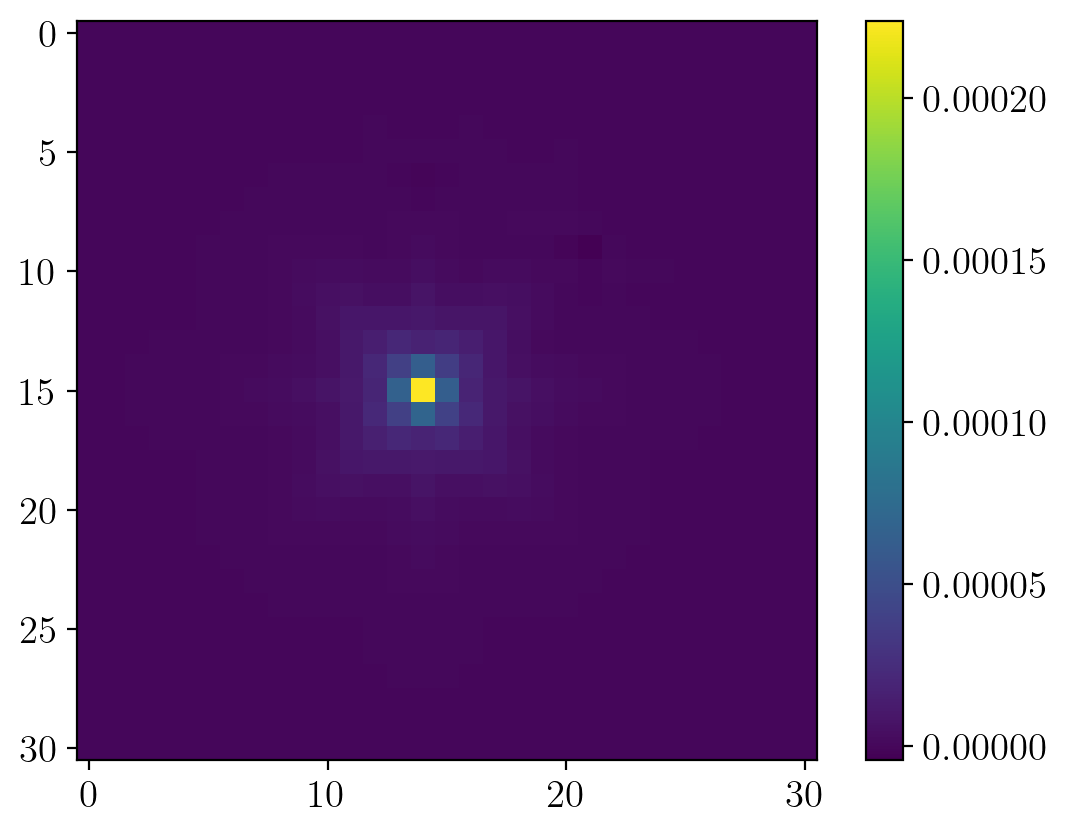

In [33]:
#plt.imshow((grad-grad__).to_numpy().reshape((31,31)))
#plt.imshow((lin_grad - lin_grad__).to_numpy().reshape((31,31)))
plt.imshow((lin_grad).to_numpy().reshape((31,31)))
plt.colorbar()

In [21]:
diff = lin_grad - lin_grad__
err_nabla_lin_J = np.sqrt(FOM.products['prod_Q'].apply2(diff, diff))[0,0]
norm_nabla_lin_J = np.sqrt(FOM.products['prod_Q'].apply2(lin_grad, lin_grad))[0,0]
rel_err_nabla_lin_J = err_nabla_lin_J / norm_nabla_lin_J
rel_err_nabla_lin_J

0.9396644920391776

In [148]:
vals = [0, 1e-2, 0.5, 1]
nabla_lin_Js = []

for val in vals:
    d = val * FOM.Q.make_array(np.ones(FOM.Q.dim)) + FOM.Q.make_array(np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim)))
    #d = FOM.Q.make_array(np.zeros(FOM.Q.dim))
    
    u_h = FOM.solve_state(q=q)
    p_h = FOM.solve_adjoint(q=q, u=u_h)
    
    lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
    lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

    nabla_lin_J = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
    
    nabla_lin_Js.append(nabla_lin_J)

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [149]:
vals = [0, 1e-2, 0.5, 1]
nabla_lin_J_rs = []

for val in vals:
    q_ = QrVrROM.Q.make_array(reductor.project_vectorarray(q, basis='parameter_basis'))
    d = val * FOM.Q.make_array(np.ones(FOM.Q.dim)) + FOM.Q.make_array(np.random.uniform(-1e-2, 1e-2, size=(1, FOM.Q.dim)))
    
    d_ = QrVrROM.Q.make_array(reductor.project_vectorarray(d, basis='parameter_basis'))
    
    u_r = QrVrROM.solve_state(q=q_)
    p_r = QrVrROM.solve_adjoint(q=q_, u=u_r)
    
    lin_u_r = QrVrROM.solve_linearized_state(q=q_, d=d_, u=u_r)
    lin_p_r = QrVrROM.solve_linearized_adjoint(q=q_, u=u_r, lin_u=lin_u_r)
    
    nabla_lin_J_r = QrVrROM.linearized_gradient(q=q_, d=d_, u=u_r, lin_p=lin_p_r)
    nabla_lin_J_r = reductor.reconstruct(nabla_lin_J_r, basis='parameter_basis')
    
    nabla_lin_J_rs.append(nabla_lin_J_r)


In [150]:
i = 0
plt.imshow((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy().reshape((31,31)))
plt.colorbar()

In [152]:
errors = []
for i in range(len(nabla_lin_Js)):
    error = np.max(np.abs((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy()))
    
    errors.append(error)
print(errors)

[7.781220057289304e-09, 3.1524082659241393e-09, 1.2255230000633038e-08, 2.6428024194019128e-08]


In [136]:
errors = []
for i in range(len(nabla_lin_Js)):
    error = np.max(np.abs((nabla_lin_Js[i] - nabla_lin_J_rs[i]).to_numpy()))
    
    errors.append(error)
print(errors)

[1.1361369630088917e-14, 9.385419611285055e-15, 4.301054175629652e-13, 8.166560384480128e-13]


In [153]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigs

N_Q = FOM.Q.dim

def matvec(d_):
    d = FOM.Q.make_array(d_)
    
    u_h = FOM.solve_state(q=q)
    p_h = FOM.solve_adjoint(q=q, u=u_h)
    
    lin_u_h = FOM.solve_linearized_state(q=q, d=d, u=u_h)
    lin_p_h = FOM.solve_linearized_adjoint(q=q, u=u_h, lin_u=lin_u_h)

    nabla_lin_J = FOM.linearized_gradient(q=q, d=d, u=u_h, lin_p=lin_p_h)
    
    return nabla_lin_J

# build matrix-free operator
G_op = LinearOperator((N_Q, N_Q), matvec=matvec, dtype=float)

eigvals, eigvecs = eigs(G_op, k=5, which='LM')

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

KeyboardInterrupt: 

In [ ]:
eigvecs

In [172]:
data_ = data['new_baseline_TR_identity_time_step']
for i in range(len(data_['q'])-1):
    d_i = data_['q'][i] - data_['q'][i+1]
    print(np.sqrt(FOM.products['prod_Q'].apply2(d_i, d_i)[0,0]))

0.27072787031271717
0.473554292689096
0.3384692848750639
0.3585667093757883
0.32115839163602616
0.24254997304554954
0.48572335681415635
0.3642871566652622
0.34278707502430916
0.3059618976628502
0.3551382928184395
0.157249540404642
0.0630921700409652
0.015093555677389809


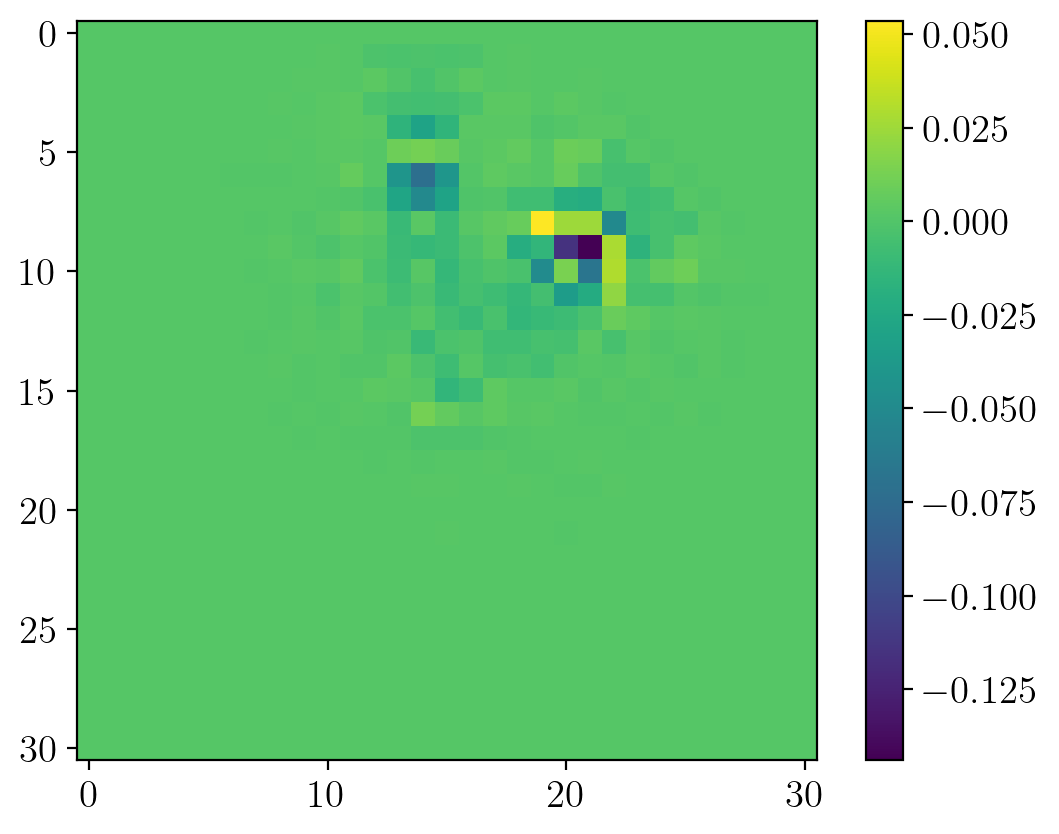

In [34]:
data_ = data['new_baseline_TR_identity_time_step']
i = 0
d_i = data_['q'][i] - data_['q'][i+1]
plt.imshow(d_i.to_numpy().reshape(31,31))
plt.colorbar()